# 04 · 影像辨識：從全連接到 CNN

這堂課處理真實影像——**MNIST 手寫數字**。先用全連接網路當基線，再升級到 **CNN（卷積神經網路）**，看看為什麼卷積特別適合影像。

## 學習目標

- 載入 MNIST，用 `DataLoader` 分批餵資料
- 理解 `nn.Conv2d` / 池化在做什麼、為何適合影像
- 比較全連接網路與 CNN 的準確率

## 1. 載入 MNIST

`torchvision` 一行就能下載。為了在這裡跑得快，我們只取一個子集（在 Colab 可以用全部 6 萬筆）。

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:52, 186kB/s]

  1%|          | 98.3k/9.91M [00:00<00:35, 280kB/s]

  2%|▏         | 197k/9.91M [00:00<00:24, 393kB/s] 

  4%|▍         | 426k/9.91M [00:00<00:13, 710kB/s]

...

 24%|██▍       | 393k/1.65M [00:00<00:02, 606kB/s]

 52%|█████▏    | 852k/1.65M [00:01<00:00, 1.16MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 5.27MB/s]

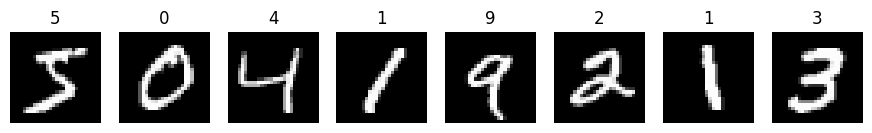

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
tfm = transforms.ToTensor()   # 轉成 [0,1] 的 tensor，形狀 (1, 28, 28)
train_full = datasets.MNIST("data", train=True, download=True, transform=tfm)
test_full = datasets.MNIST("data", train=False, download=True, transform=tfm)
train = Subset(train_full, range(8000))   # 子集，加速；Colab 可拿掉
test = Subset(test_full, range(2000))
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=256)

# 看幾張長相
fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for ax, (img, label) in zip(axes, train):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(str(label)); ax.axis("off")
plt.show()

In [2]:
def evaluate(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            correct += (model(xb).argmax(1) == yb).sum().item()
    return correct / len(test)

def train_model(model, epochs=3, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    return model

## 2. 基線：全連接網路

把 28×28 的圖**攤平成 784 維向量**丟進 MLP。能用，但攤平就把「哪個像素挨著哪個」的空間結構全丟了。

In [3]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 10),
)
train_model(mlp)
print(f"全連接網路準確率：{evaluate(mlp):.1%}")

全連接網路準確率：89.1%


## 3. 升級：CNN

**卷積層**用一個小窗口（kernel）滑過整張圖，偵測邊緣、轉角等**局部圖樣**，而且同一個 kernel 在每個位置共用權重——既保留空間結構、參數又少。配上**池化**縮小尺寸。

In [4]:
cnn = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28→14
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14→7
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 10),
)
train_model(cnn)
print(f"CNN 準確率：{evaluate(cnn):.1%}")

CNN 準確率：94.3%


即使只用一小撮資料、訓練幾輪，CNN 通常就贏過全連接網路——因為它**尊重影像的空間結構**。這也是為什麼所有現代視覺模型都建立在卷積（或其變體）之上。

## 小結

- `DataLoader` 把資料分批、打亂，餵給訓練迴圈。
- 全連接網路把圖攤平，丟掉空間結構；**CNN 用卷積保留局部圖樣、共用權重**。
- 同樣條件下，CNN 在影像上通常勝過 MLP。

## 練習

1. 把訓練子集從 8000 加到全部（`range(8000)` 改成整個 `train_full`），CNN 準確率衝到多少？
2. 在 CNN 後段加一層 `nn.Linear(…, 64)` + ReLU 再接輸出，有幫助嗎？

下一課，認識深度學習最大的敵人之一——**過擬合**，以及怎麼對付它。